# Plasma-Photocurrent THz Emission Driven by Bright Squeezed Vacuum

Local-current (Stage 5) simulation of THz generation in a laser-induced gas
plasma driven by a strong coherent 800 nm fundamental plus a weak 400 nm
bright squeezed vacuum (BSV) second harmonic. The setting follows the
coherent-plus-BSV configuration of Wang et al. 2026 (PRA 113, L021501), the
photocurrent template of Sun et al. 2022, and the current-derivative THz
source of Schuh et al. 2013.

Spec: `wiki/simulations/thz-plasma-bsv-photocurrent-notebook.md`.

**Field representation (stated per project guardrails)**

- Driving-field photon statistics: single-mode squeezed-vacuum **Wigner**
  samples with explicit symmetric-to-normal ordering corrections, so the
  reported $g^{(2)}(0)$ is the normally ordered photon correlation. Proof
  target: $g^{(2)}(0) = 3 + 1/\langle n\rangle$ with
  $\langle n\rangle = \sinh^2 r$.
- Plasma dynamics: **Husimi-Q** coherent-amplitude samples (Wang 2026 style
  coherent-state decomposition). Each sample defines a classical waveform and
  the ensemble observables are Q-weighted coherent-component averages
  (diagonal approximation, as in Wang 2026 / Lyu 2025).
- All statistics quoted for the *emitted* THz field are **classical
  stochastic statistics** of the sampled ensemble, not normally ordered
  photon correlations of an emitted quantum mode.

**Symmetry expectation.** The BSV component has zero mean and its Q
distribution is invariant under $\alpha \to -\alpha$, which flips the sign of
the injected current asymmetry. The ensemble-mean THz field should therefore
vanish within Monte Carlo error, while the ensemble-averaged spectrum
$\langle |E_\mathrm{THz}(\nu)|^2 \rangle$ stays finite: incoherent,
thermal-like broadband THz emission.

Units: atomic units (a.u.) for microscopic dynamics; time axes also shown in
fs and spectra in THz. THz field amplitudes are in arbitrary units (local
single-atom current response, no macroscopic propagation).

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.signal import lfilter

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "wiki").exists())
try:
    import stochastic_em_theory  # noqa: F401
except ImportError:
    sys.path.insert(0, str(repo_root / "code" / "src"))

from stochastic_em_theory.fields import (
    sample_single_mode_husimi_q,
    sample_single_mode_wigner,
)
from stochastic_em_theory.observables import (
    analytic_single_mode_g2,
    analytic_single_mode_n,
    estimate_single_mode_moments,
)

AU_TIME_FS = 0.0241888432651  # 1 a.u. of time in fs
AU_FREQ_THZ = 1.0e3 / AU_TIME_FS  # (cycles per a.u. of time) -> THz
AU_INTENSITY_WCM2 = 3.50944758e16  # intensity of E = 1 a.u. in W/cm^2

## Parameters

The fundamental is a strong coherent 800 nm pulse; the BSV is a weak 400 nm
second-harmonic mode whose Q-ensemble mean cycle-averaged intensity is a fixed
fraction of the fundamental intensity. The gas is argon-like
($I_p = 15.76\ \mathrm{eV}$). The current damping rate is an effective value
chosen so the current surge decays inside the simulation window; it stands in
for collisional damping and plasma screening, which are not modeled.

In [2]:
params = {
    "seed": 20260610,
    # coherent fundamental (800 nm)
    "lambda_w_nm": 800.0,
    "intensity_w_Wcm2": 1.0e14,
    "fwhm_fs": 35.0,            # intensity FWHM of the Gaussian envelope
    # BSV second harmonic (400 nm)
    "r": 1.0,                   # squeezing parameter
    "squeeze_phase": 0.0,       # squeezing-ellipse orientation
    "intensity_ratio": 0.02,    # Q-mean cycle-averaged I_2w / I_w
    # gas and plasma response
    "Ip_au": 0.579,             # argon ionization potential (15.76 eV)
    "nu_coll_au": 5.0e-4,       # effective current damping, 1/nu ~ 48 fs
    # numerics
    "n_shots": 400,             # Husimi-Q realizations for plasma dynamics
    "n_wigner": 2_000_000,      # Wigner samples for g2(0) of the drive
    "t_span_fs": 200.0,
    "dt_au": 0.4,
    "thz_cut_THz": 60.0,        # low-pass edge of the detected THz band
}

omega_w = 45.5633525316 / params["lambda_w_nm"]  # a.u.
e_w = np.sqrt(params["intensity_w_Wcm2"] / AU_INTENSITY_WCM2)  # a.u.
sigma_t = params["fwhm_fs"] / (2.0 * np.sqrt(np.log(2.0))) / AU_TIME_FS
half_span = 0.5 * params["t_span_fs"] / AU_TIME_FS
t = np.arange(-half_span, half_span, params["dt_au"])
t_fs = t * AU_TIME_FS
envelope = np.exp(-(t**2) / (2.0 * sigma_t**2))
rng = np.random.default_rng(params["seed"])

results_dir = repo_root / "results" / "20260610-thz-plasma-bsv-notebook"
results_dir.mkdir(parents=True, exist_ok=True)

print(f"omega (800 nm) = {omega_w:.5f} a.u., E_w = {e_w:.4f} a.u.")
print(f"time grid: {t.size} steps, dt = {params['dt_au']} a.u. "
      f"= {params['dt_au'] * AU_TIME_FS * 1e3:.2f} as")

omega (800 nm) = 0.05695 a.u., E_w = 0.0534 a.u.
time grid: 20671 steps, dt = 0.4 a.u. = 9.68 as


## Driving-field statistics: $g^{(2)}(0)$ of the BSV mode

Wigner sampling gives symmetrically ordered moments. The normally ordered
photon-counting moments follow from the project's ordering corrections

$$
\langle a^\dagger a\rangle = \langle|\alpha|^2\rangle_W - \tfrac12,
\qquad
\langle a^{\dagger 2} a^2\rangle
 = \langle|\alpha|^4\rangle_W - 2\langle|\alpha|^2\rangle_W + \tfrac12 ,
$$

and the corrected $g^{(2)}(0)$ is validated against the analytic
single-mode squeezed-vacuum value $3 + 1/\langle n\rangle$.

The plasma dynamics below use a *separate* Husimi-Q ensemble of coherent
amplitudes $\alpha_j$. The field-scale convention is: the conversion factor
$\varepsilon$ is fixed so that the Q-ensemble mean cycle-averaged intensity of
the $2\omega$ component, $\varepsilon^2\langle|\alpha|^2\rangle_Q / 2$ with
$\langle|\alpha|^2\rangle_Q = \langle n\rangle + 1$, equals
`intensity_ratio` times the fundamental cycle-averaged intensity $E_\omega^2/2$.

In [3]:
alpha_wigner = sample_single_mode_wigner(
    r=params["r"], phase=params["squeeze_phase"], shots=params["n_wigner"], rng=rng
)
moments = estimate_single_mode_moments(alpha_wigner)
n_analytic = analytic_single_mode_n(params["r"])
g2_analytic = analytic_single_mode_g2(params["r"])

print("BSV driving mode (single-mode squeezed vacuum, r = %.2f)" % params["r"])
print(f"  <n>:    estimate {moments.n_corrected:.4f}   analytic {n_analytic:.4f}")
print(f"  g2(0):  estimate {moments.g2_corrected:.4f}   analytic {g2_analytic:.4f}"
      "   (ordering-corrected, normally ordered)")
print(f"  g2(0) naive Wigner moment ratio: {moments.g2_naive:.4f}"
      "   <- NOT a photon-counting g2; shown for contrast")

# Husimi-Q ensemble that drives the plasma dynamics
alpha_q = sample_single_mode_husimi_q(
    r=params["r"], phase=params["squeeze_phase"], shots=params["n_shots"], rng=rng
)
mean_abs2_q = n_analytic + 1.0  # <|alpha|^2>_Q for squeezed vacuum
eps_2w = e_w * np.sqrt(params["intensity_ratio"] / mean_abs2_q)

print(f"\nHusimi-Q ensemble: {alpha_q.size} shots, "
      f"<|alpha|^2>_Q sample {np.mean(np.abs(alpha_q)**2):.3f} "
      f"(analytic {mean_abs2_q:.3f})")
print(f"field-scale factor eps = {eps_2w:.5f} a.u. per unit |alpha|")

BSV driving mode (single-mode squeezed vacuum, r = 1.00)
  <n>:    estimate 1.3814   analytic 1.3811
  g2(0):  estimate 3.7218   analytic 3.7241   (ordering-corrected, normally ordered)
  g2(0) naive Wigner moment ratio: 2.9282   <- NOT a photon-counting g2; shown for contrast

Husimi-Q ensemble: 400 shots, <|alpha|^2>_Q sample 2.622 (analytic 2.381)
field-scale factor eps = 0.00489 a.u. per unit |alpha|


## Stochastic two-color driving field

Each shot $j$ uses the classical waveform

$$
E_j(t) = f(t)\left[E_\omega\cos(\omega t)
 + \varepsilon\,\mathrm{Re}\!\left(\alpha_j e^{2i\omega t}\right)\right],
$$

with Gaussian envelope $f(t)$. With squeezing phase $0$, the anti-squeezed
quadrature $p_\alpha$ couples to $\sin(2\omega t)$, i.e. to a relative
two-color phase of $\pm\pi/2$ — exactly the phase that maximizes photocurrent
injection asymmetry. Each shot therefore emits efficiently, but with a sign
set by $\mathrm{sgn}(p_{\alpha,j})$, which is symmetric in the ensemble.

Baselines: (i) one-color coherent fundamental only; (ii) a deterministic
two-color field with the same mean $2\omega$ intensity and relative phase
$\pi/2$.

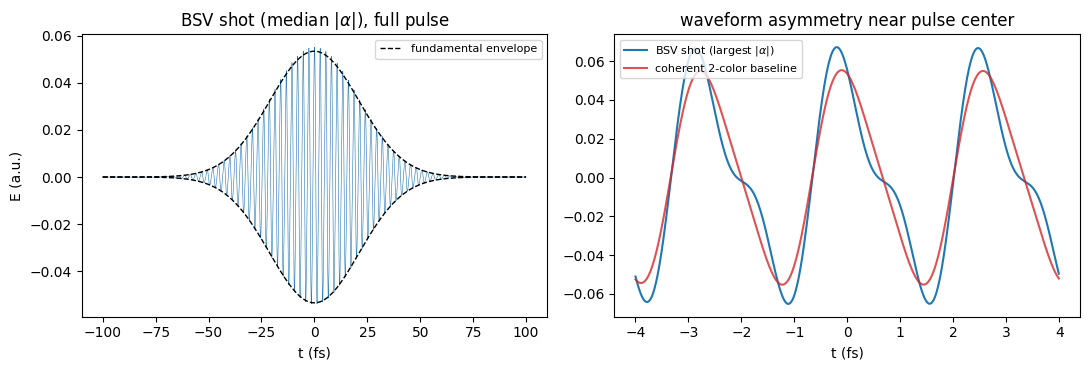

In [4]:
carrier_2w = np.exp(2j * omega_w * t)
e_fund = e_w * np.cos(omega_w * t) * envelope


def two_color_field(alpha_2w):
    """Total driving field, shape (n_t, n_shots), for complex 2w amplitudes."""
    alpha_2w = np.atleast_1d(np.asarray(alpha_2w, dtype=np.complex128))
    second = eps_2w * np.real(carrier_2w[:, None] * alpha_2w[None, :])
    return e_fund[:, None] + envelope[:, None] * second


alpha_baseline = 1j * np.sqrt(mean_abs2_q)  # same mean intensity, theta = pi/2
field_bsv = two_color_field(alpha_q)
field_coh = two_color_field(alpha_baseline)
field_one = e_fund[:, None]

shot_demo = int(np.argsort(np.abs(alpha_q))[params["n_shots"] // 2])  # median shot
shot_hot = int(np.argmax(np.abs(alpha_q)))                            # largest |alpha|

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(t_fs, field_bsv[:, shot_demo], lw=0.4, color="tab:blue")
axes[0].plot(t_fs, e_w * envelope, "k--", lw=1, label="fundamental envelope")
axes[0].plot(t_fs, -e_w * envelope, "k--", lw=1)
axes[0].set_xlabel("t (fs)")
axes[0].set_ylabel("E (a.u.)")
axes[0].set_title("BSV shot (median $|\\alpha|$), full pulse")
axes[0].legend(loc="upper right", fontsize=8)
zoom = (t_fs > -4) & (t_fs < 4)
axes[1].plot(t_fs[zoom], field_bsv[zoom, shot_hot], color="tab:blue",
             label="BSV shot (largest $|\\alpha|$)")
axes[1].plot(t_fs[zoom], field_coh[zoom, 0], color="tab:red", alpha=0.8,
             label="coherent 2-color baseline")
axes[1].set_xlabel("t (fs)")
axes[1].set_title("waveform asymmetry near pulse center")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(results_dir / "fig_driving_field.png", dpi=160)
plt.show()

## Plasma photocurrent model

Per shot, in atomic units ($e = m_e = \hbar = 1$, electron charge sign
absorbed into the arbitrary sign of $E_\mathrm{THz}$):

$$
\frac{dn_e}{dt} = w(|E_j|)\,(N_0 - n_e), \qquad
\frac{dJ}{dt} + \nu J = n_e(t)\,E_j(t), \qquad
E_{\mathrm{THz},j}(t) \propto \left.\frac{dJ}{dt}\right|_{\nu < \nu_\mathrm{cut}} .
$$

- $w$ is the hydrogen-like quasi-static tunneling rate
  $w = 4(2I_p)^{5/2}|E|^{-1}\exp[-2(2I_p)^{3/2}/(3|E|)]$. This is a standard
  ADK-form proxy adequate for waveform-asymmetry physics; it is **not** a
  quantitative ionization model (no PPT corrections, no barrier suppression).
- $n_e$ has the exact solution
  $n_e(t) = N_0\,(1 - e^{-\int^t w\,dt'})$ with $N_0 = 1$ (densities
  normalized; output in arbitrary units).
- The current ODE is integrated with an exact-decay recursion
  (`scipy.signal.lfilter`), and $dJ/dt = n_e E - \nu J$ algebraically.
- The emitted THz band is selected with a super-Gaussian low-pass
  $\exp[-(\nu/\nu_\mathrm{cut})^8]$ applied in the frequency domain.

In [5]:
def quasistatic_rate(abs_field, ip):
    """Hydrogen-like quasi-static tunneling rate in a.u. (ADK-form proxy)."""
    abs_field = np.maximum(abs_field, 1.0e-6)
    kappa3 = (2.0 * ip) ** 1.5
    return 4.0 * (2.0 * ip) ** 2.5 / abs_field * np.exp(-2.0 * kappa3 / (3.0 * abs_field))


def run_photocurrent(field, *, dt, ip, nu):
    """Photocurrent response for field (n_t, n_shots): n_e/N0, J, dJ/dt."""
    rate = quasistatic_rate(np.abs(field), ip)
    n_e = 1.0 - np.exp(-dt * np.cumsum(rate, axis=0))
    drive = n_e * field
    j = lfilter([dt], [1.0, -np.exp(-nu * dt)], drive, axis=0)
    return n_e, j, drive - nu * j


def thz_band(djdt, *, dt, cut_thz, order=8):
    """Band-limit dJ/dt to the THz range. Returns freqs (THz), spectrum, waveform."""
    freqs_thz = np.fft.rfftfreq(djdt.shape[0], d=dt) * AU_FREQ_THZ
    spec = np.fft.rfft(djdt, axis=0) * dt
    window = np.exp(-((freqs_thz / cut_thz) ** order))
    waveform = np.fft.irfft(spec * window[:, None], n=djdt.shape[0], axis=0) / dt
    return freqs_thz, spec * window[:, None], waveform

bsv          final ionization fraction: mean 4.273e-03, max 3.384e-02
coherent_2w  final ionization fraction: mean 3.302e-03, max 3.302e-03
one_color    final ionization fraction: mean 2.070e-03, max 2.070e-03


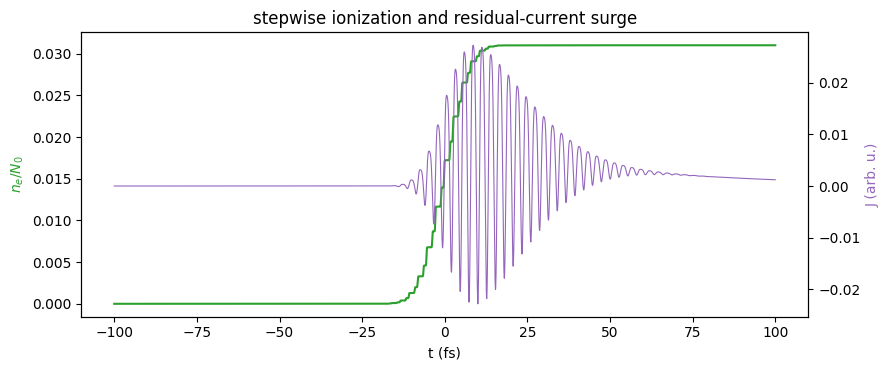

In [6]:
cases = {}
for name, field in [("bsv", field_bsv), ("coherent_2w", field_coh), ("one_color", field_one)]:
    n_e, j, djdt = run_photocurrent(
        field, dt=params["dt_au"], ip=params["Ip_au"], nu=params["nu_coll_au"]
    )
    freqs_thz, spec, e_thz = thz_band(
        djdt, dt=params["dt_au"], cut_thz=params["thz_cut_THz"]
    )
    cases[name] = {"n_e": n_e, "j": j, "spec": spec, "e_thz": e_thz}
    print(f"{name:12s} final ionization fraction: "
          f"mean {n_e[-1].mean():.3e}, max {n_e[-1].max():.3e}")

fig, ax1 = plt.subplots(figsize=(9, 3.8))
ax2 = ax1.twinx()
ax1.plot(t_fs, cases["bsv"]["n_e"][:, shot_hot], color="tab:green",
         label="$n_e/N_0$ (largest-$|\\alpha|$ shot)")
ax2.plot(t_fs, cases["bsv"]["j"][:, shot_hot], color="tab:purple", lw=0.8,
         label="$J$ (same shot)")
ax1.set_xlabel("t (fs)")
ax1.set_ylabel("$n_e / N_0$", color="tab:green")
ax2.set_ylabel("J (arb. u.)", color="tab:purple")
ax1.set_title("stepwise ionization and residual-current surge")
fig.tight_layout()
fig.savefig(results_dir / "fig_dynamics_example.png", dpi=160)
plt.show()

## THz waveform: ensemble mean field and fluctuation

The plot shows the ensemble-mean THz field $\langle E_\mathrm{THz}(t)\rangle$
together with the shot-to-shot fluctuation band ($\pm 1\sigma$), a few
individual realizations, and the deterministic coherent two-color baseline.
For the zero-mean BSV second harmonic, the mean is expected to vanish within
Monte Carlo error while the fluctuation band stays large.

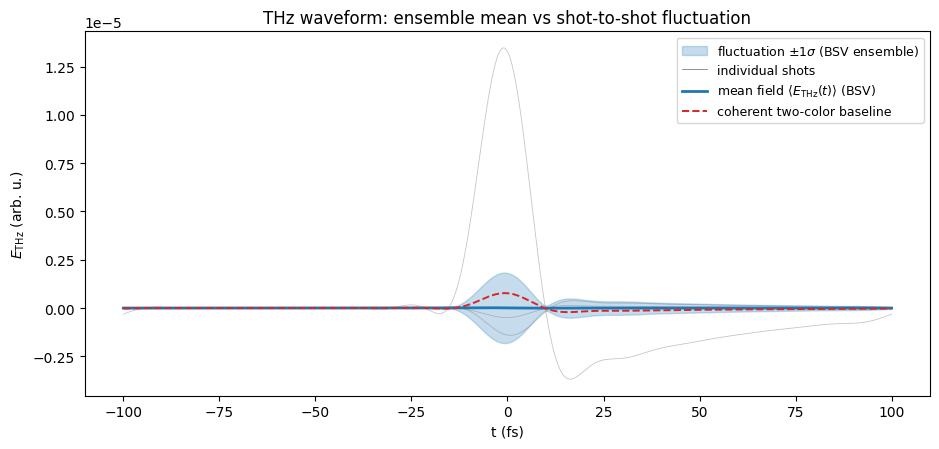

max|<E_THz>| / max sigma = 0.008 (Monte Carlo floor ~ 1/sqrt(N) = 0.050)


In [7]:
e_bsv = cases["bsv"]["e_thz"]
mean_wave = e_bsv.mean(axis=1)
std_wave = e_bsv.std(axis=1)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.fill_between(t_fs, mean_wave - std_wave, mean_wave + std_wave,
                color="tab:blue", alpha=0.25,
                label=r"fluctuation $\pm 1\sigma$ (BSV ensemble)")
for k in (shot_demo, shot_hot, 0):
    ax.plot(t_fs, e_bsv[:, k], lw=0.6, alpha=0.45, color="gray")
ax.plot([], [], lw=0.6, color="gray", label="individual shots")
ax.plot(t_fs, mean_wave, color="tab:blue", lw=2.0,
        label=r"mean field $\langle E_\mathrm{THz}(t)\rangle$ (BSV)")
ax.plot(t_fs, cases["coherent_2w"]["e_thz"][:, 0], "--", color="tab:red", lw=1.4,
        label="coherent two-color baseline")
ax.set_xlabel("t (fs)")
ax.set_ylabel(r"$E_\mathrm{THz}$ (arb. u.)")
ax.set_title("THz waveform: ensemble mean vs shot-to-shot fluctuation")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(results_dir / "fig_thz_waveform.png", dpi=160)
plt.show()

symmetry_ratio = np.max(np.abs(mean_wave)) / np.max(std_wave)
print(f"max|<E_THz>| / max sigma = {symmetry_ratio:.3f} "
      f"(Monte Carlo floor ~ 1/sqrt(N) = {1.0 / np.sqrt(params['n_shots']):.3f})")

## Ensemble-averaged THz spectrum

Total spectrum $\langle|E_\mathrm{THz}(\nu)|^2\rangle$ (mean field plus
fluctuations) versus the coherent part $|\langle E_\mathrm{THz}(\nu)\rangle|^2$
(mean field only); their difference is the incoherent fluctuation spectrum.
Averaging is over field amplitudes *after* the spectral magnitude is taken for
the total, and *before* for the coherent part. The half-ensemble curve is the
Monte Carlo convergence check.

Note: the roll-off above $\sim$60 THz is the detection low-pass filter
(`thz_cut_THz`), not an intrinsic emission bandwidth.

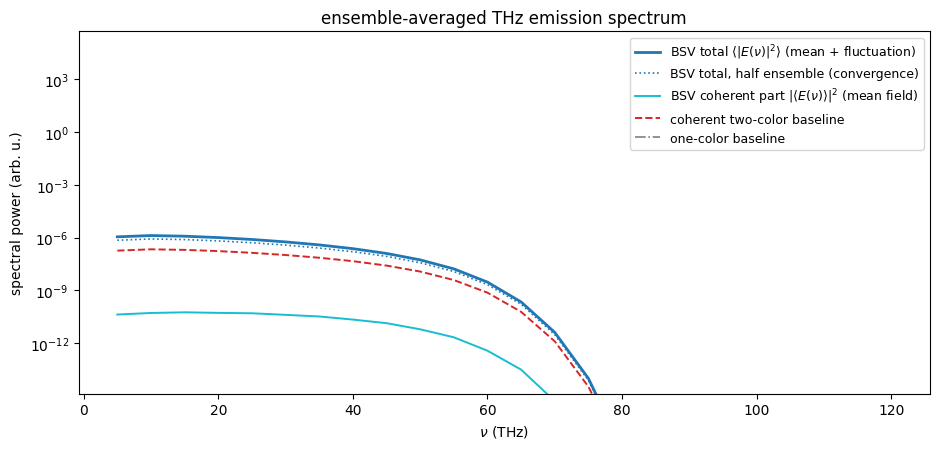

In [8]:
spec_bsv = cases["bsv"]["spec"]
s_total = np.mean(np.abs(spec_bsv) ** 2, axis=1)
s_coherent = np.abs(spec_bsv.mean(axis=1)) ** 2
s_half = np.mean(np.abs(spec_bsv[:, : params["n_shots"] // 2]) ** 2, axis=1)
s_baseline = np.abs(cases["coherent_2w"]["spec"][:, 0]) ** 2
s_one = np.abs(cases["one_color"]["spec"][:, 0]) ** 2

mask = (freqs_thz > 0.0) & (freqs_thz <= 120.0)
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.semilogy(freqs_thz[mask], s_total[mask], color="tab:blue", lw=2,
            label=r"BSV total $\langle|E(\nu)|^2\rangle$ (mean + fluctuation)")
ax.semilogy(freqs_thz[mask], s_half[mask], ":", color="tab:blue", lw=1.2,
            label="BSV total, half ensemble (convergence)")
ax.semilogy(freqs_thz[mask], s_coherent[mask], color="tab:cyan", lw=1.4,
            label=r"BSV coherent part $|\langle E(\nu)\rangle|^2$ (mean field)")
ax.semilogy(freqs_thz[mask], s_baseline[mask], "--", color="tab:red", lw=1.4,
            label="coherent two-color baseline")
ax.semilogy(freqs_thz[mask], s_one[mask], "-.", color="gray", lw=1.2,
            label="one-color baseline")
ax.set_xlabel(r"$\nu$ (THz)")
ax.set_ylabel("spectral power (arb. u.)")
ax.set_title("ensemble-averaged THz emission spectrum")
ax.set_ylim(bottom=max(s_total[mask].max() * 1e-9, 1e-30))
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(results_dir / "fig_thz_spectrum.png", dpi=160)
plt.show()

## Summary statistics

$g^{(2)}(0)$ of the driving BSV mode (quantum, ordering-corrected) and the
zero-delay energy-fluctuation ratio of the emitted THz,
$g^{(2)}_\mathrm{THz} = \langle U^2\rangle / \langle U\rangle^2$ with
$U_j = \int |E_{\mathrm{THz},j}|^2 dt$. The latter is a **classical**
statistic of the stochastic ensemble.

If the plasma density were fixed, the per-shot THz amplitude would be linear in
the anti-squeezed Gaussian quadrature ($E_\mathrm{THz}\propto p_\alpha$,
$U\propto p_\alpha^2$) and the linearized expectation would be
$\langle p^4\rangle/\langle p^2\rangle^2 = 3$. In the full model the tunneling
rate is exponentially sensitive to the peak field, so large-$|\alpha|$ shots
both ionize more *and* inject more asymmetric current: rare anti-squeezed
outliers dominate $\langle U\rangle$ (the mean far exceeds the median) and
push $g^{(2)}_\mathrm{THz}$ well above 3. The ionization nonlinearity
*amplifies* the BSV superbunching — qualitatively consistent with, and
stronger than, the bunched/super-Poissonian THz predicted by Wang 2026. A
bootstrap confidence interval is reported because heavy-tailed ensembles
converge slowly.

In [9]:
dt = params["dt_au"]
u_bsv = np.sum(cases["bsv"]["e_thz"] ** 2, axis=0) * dt
u_coh = float(np.sum(cases["coherent_2w"]["e_thz"][:, 0] ** 2) * dt)
u_one = float(np.sum(cases["one_color"]["e_thz"][:, 0] ** 2) * dt)
g2_thz = float(np.mean(u_bsv**2) / np.mean(u_bsv) ** 2)

boot = rng.choice(u_bsv, size=(2000, u_bsv.size), replace=True)
g2_boot = np.mean(boot**2, axis=1) / np.mean(boot, axis=1) ** 2
g2_ci = np.percentile(g2_boot, [2.5, 97.5])

print("=" * 64)
print("DRIVING FIELD (single-mode BSV, quantum photon statistics)")
print(f"  <n> = {moments.n_corrected:.4f}   (analytic {n_analytic:.4f})")
print(f"  g2(0) = {moments.g2_corrected:.4f}   (analytic 3 + 1/<n> = {g2_analytic:.4f})")
print("-" * 64)
print("EMITTED THz (classical ensemble statistics, arb. energy units)")
print(f"  <U>_BSV = {np.mean(u_bsv):.3e}   median U = {np.median(u_bsv):.3e}"
      "   (mean >> median: heavy tail)")
print(f"  g2_THz(0) = <U^2>/<U>^2 = {g2_thz:.3f}   "
      f"[bootstrap 95% CI {g2_ci[0]:.1f} - {g2_ci[1]:.1f}]")
print("    linearized fixed-density value would be 3; the ionization")
print("    nonlinearity amplifies the BSV superbunching well beyond it")
print(f"  coherent two-color baseline U = {u_coh:.3e}")
print(f"  one-color baseline U = {u_one:.3e} "
      f"({u_one / max(u_coh, 1e-300):.2e} of two-color)")
print("-" * 64)
print("SYMMETRY CHECK")
print(f"  max|<E_THz>| / max sigma = {symmetry_ratio:.3f}; "
      "a value at the 1/sqrt(N) Monte Carlo floor means the")
print("  ensemble-mean THz field vanishes, as required by the alpha -> -alpha")
print("  symmetry of zero-mean BSV: the emission is incoherent and bunched.")
print("=" * 64)

DRIVING FIELD (single-mode BSV, quantum photon statistics)
  <n> = 1.3814   (analytic 1.3811)
  g2(0) = 3.7218   (analytic 3 + 1/<n> = 3.7241)
----------------------------------------------------------------
EMITTED THz (classical ensemble statistics, arb. energy units)
  <U>_BSV = 1.634e-09   median U = 1.065e-10   (mean >> median: heavy tail)
  g2_THz(0) = <U^2>/<U>^2 = 20.176   [bootstrap 95% CI 10.4 - 28.1]
    linearized fixed-density value would be 3; the ionization
    nonlinearity amplifies the BSV superbunching well beyond it
  coherent two-color baseline U = 2.803e-10
  one-color baseline U = 9.851e-20 (3.51e-10 of two-color)
----------------------------------------------------------------
SYMMETRY CHECK
  max|<E_THz>| / max sigma = 0.008; a value at the 1/sqrt(N) Monte Carlo floor means the
  ensemble-mean THz field vanishes, as required by the alpha -> -alpha
  symmetry of zero-mean BSV: the emission is incoherent and bunched.


## Discussion and caveats

- **Mean field vs fluctuation.** The coherent two-color baseline emits a
  deterministic THz transient. The BSV-driven ensemble emits comparably strong
  per-shot transients, but with signs set by the anti-squeezed quadrature of
  the sampled $2\omega$ amplitude; the ensemble-mean field is consistent with
  zero and all the emitted energy lives in the fluctuation term. This is the
  symmetry result anticipated in `wiki/models/thz-plasma-emission-model.md`
  and is consistent with the incoherent, bunched THz of Wang 2026.
- **Superbunched THz energy.** $g^{(2)}_\mathrm{THz}$ comes out well above
  both the thermal value 2 and the linearized quadrature-squared value 3,
  because the exponential ionization nonlinearity lets rare anti-squeezed
  outlier shots dominate the ensemble energy (mean $\gg$ median). This is a
  candidate entry for the non-Gaussian novelty path of the wiki, but with 400
  shots the value carries a wide bootstrap interval — treat the number as
  regime-indicating, not converged.
- **What is and is not quantum here.** The drive's $g^{(2)}(0)$ is a genuine
  normally ordered quantity via Wigner ordering corrections. The THz-side
  $g^{(2)}_\mathrm{THz}$ is a classical energy-fluctuation ratio of the
  Q-sampled ensemble; certifying photon statistics of the emitted THz mode
  would require an emitted-field quantum model (Stage 6 of the roadmap).
- **Model limitations.** Single-point local current (no propagation, phase
  matching, or plasma screening); ADK-form rate proxy; effective current
  damping; single-mode BSV (real BSV is multimode with gain-dependent Schmidt
  weights); diagonal (coherent-component) approximation for the dynamics.
- **Next steps per spec.** Scan squeezing angle and `intensity_ratio`,
  post-select on per-shot $|\alpha|$ bins, and run the pure zero-mean BSV
  case (no coherent fundamental) as a dedicated symmetry experiment.

In [10]:
try:
    commit = subprocess.run(
        ["git", "rev-parse", "HEAD"], cwd=repo_root,
        capture_output=True, text=True, check=True,
    ).stdout.strip()
except Exception:
    commit = "unknown"

with open(results_dir / "params.yaml", "w") as fh:
    yaml.safe_dump(params, fh, sort_keys=False)

manifest = {
    "run_id": "20260610-thz-plasma-bsv-notebook",
    "created": "2026-06-10",
    "code_entrypoint": "code/notebooks/thz_plasma_bsv_photocurrent.ipynb",
    "git_commit": commit,
    "parameter_file": "params.yaml",
    "random_seeds": [params["seed"]],
    "observable": (
        "driving-field g2(0); ensemble mean/std THz waveform; "
        "ensemble-averaged THz spectrum (total, coherent part); "
        "classical THz energy-fluctuation ratio"
    ),
    "notes": (
        f"coherent 800 nm + BSV 400 nm photocurrent model; "
        f"g2_drive={moments.g2_corrected:.4f} (analytic {g2_analytic:.4f}); "
        f"g2_THz_classical={g2_thz:.3f}; "
        f"max|<E>|/max(sigma)={symmetry_ratio:.3f}"
    ),
}
with open(results_dir / "manifest.yaml", "w") as fh:
    yaml.safe_dump(manifest, fh, sort_keys=False)

print(f"results written to {results_dir}")
for path in sorted(results_dir.iterdir()):
    print(f"  {path.name}")

results written to /Users/20490412/Documents/stochastic_em_theory/results/20260610-thz-plasma-bsv-notebook
  fig_driving_field.png
  fig_dynamics_example.png
  fig_thz_spectrum.png
  fig_thz_waveform.png
  manifest.yaml
  params.yaml
